# 权重衰减

本节我们将介绍一些正则化模型的技术,
仅仅通过简单的限制特征数量(在多项式回归中体现为限制阶数),可能仍然使模型在过简单和过复杂中徘徊,我们需要一个更细粒度的工具来调整函数的复杂性,使其达到一个合适的平衡位置。
## 范数与权重衰减

训练参数化机器学习模型时,权重衰减(weight decay)是最广泛使用的正则化的技术之一,它通常也被称为L2正则化

不加权重衰减：学生死记硬背所有训练题的答案（包括错题、噪声），考试（测试集）成绩很差。

加权重衰减：老师告诉学生“答案不要写得太复杂，尽量用最简单的公式”，学生被迫总结规律，考试成绩反而更好。

In [14]:
import torch
from torch import nn
from d2l import torch as d2l

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

## 从零开始


初始化模型参数

In [15]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]



## 定义L2范数惩罚

In [16]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

## 定义训练代码实现

In [17]:
import torch
from d2l import torch as d2l

def train(lambd):
    """
    训练模型并应用 L2 正则化（权重衰减）
    lambd: 正则化项的系数 λ (超参数)
    """
    # 1. 初始化参数 (假设已定义好 init_params 函数)
    w, b = init_params()

    # 2. 定义网络和损失函数
    # 使用 lambda 定义一个简单的线性回归前向传播
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss

    # 3. 设置超参数
    num_epochs, lr = 100, 0.003
    batch_size = 5 # 假设 batch_size 已在外部定义或此处设定

    # 4. 初始化可视化工具
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])

    # 5. 训练循环
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # --- 核心改进：在原始损失中加入 L2 惩罚项 ---
            # 损失函数 = 均方误差 + λ * L2范数(w)
            # l2_penalty(w) 通常定义为 (w**2).sum() / 2
            l = loss(net(X), y) + lambd * l2_penalty(w)

            l.sum().backward()     # 反向传播
            d2l.sgd([w, b], lr, batch_size) # 手动更新参数

        # 6. 周期性记录和绘图
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))

    # 7. 查看最终权重的 L2 范数（用于验证正则化效果）
    print('w的L2范数是:', torch.norm(w).item())

##忽略正则化直接训练

w的L2范数是: 14.13120174407959


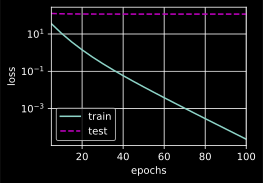

In [18]:
train(lambd=0)

##使用权重衰减

w的L2范数是: 0.3736620545387268


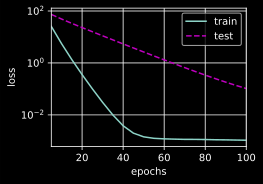

In [19]:
train(lambd=3)

## 简洁实现

In [20]:
import torch
from torch import nn
from d2l import torch as d2l

def train_concise(wd):
    """
    使用 PyTorch 高级 API 训练模型并应用权重衰减
    wd: weight_decay (等同于之前代码中的 lambd)
    """
    # 1. 定义模型并初始化参数
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_() # 使用标准正态分布初始化

    # 2. 定义损失函数
    loss = nn.MSELoss(reduction='none')

    # 3. 设置超参数
    num_epochs, lr = 100, 0.003

    # 4. 核心：通过优化器实现权重衰减
    # 分组设置参数：
    # - 权重(weight)部分：应用 weight_decay (wd)
    # - 偏置(bias)部分：不进行衰减（默认 weight_decay 为 0）
    trainer = torch.optim.SGD([
        {"params": net[0].weight, 'weight_decay': wd},
        {"params": net[0].bias}
    ], lr=lr)

    # 5. 可视化工具
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])

    # 6. 训练循环
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad() # 梯度清零
            l = loss(net(X), y)
            l.mean().backward() # 反向传播（这里取平均值）
            trainer.step()      # 更新参数

        # 7. 绘图记录
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))

    print('w的L2范数:', net[0].weight.norm().item())

w的L2范数: 14.723620414733887


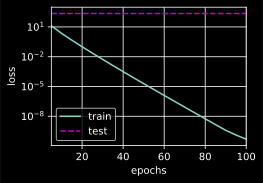

In [21]:
train_concise(0)

w的L2范数: 0.4110286235809326


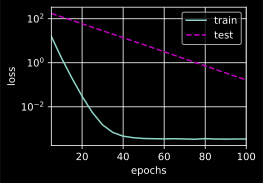

In [22]:
train_concise(3)

正则化是处理过拟合的常用方法:在训练集的损失函数中加入惩罚项,以降低学习到的模型的复杂度。

 保持模型简单的一个特别的选择是使用L2惩罚的权重衰减。这会导致学习算法更新步骤中的权重衰减。

 权重衰减功能在深度学习框架的优化器中提供。 weight_decay

 在同一训练代码实现中,不同的参数集可以有不同的更新行为。